# PHASE 4: PRE-OPERATIVE SURGICAL CONTEXT & HYBRID COST MAP GENERATION
---
**Thesis:** 3D Resection & Surgical Planning of Brain Tumors Using DL + RL  
**Framework:** PyTorch + MONAI + SciPy  
**Environment:** Kaggle / Google Colab (T4 GPU)  

## Objective
To transform binary Deep Learning tissue segmentations into a kinematically-aware surgical environment. This phase bridges the Perception and Planning modules by replacing sparse binary maps with continuous probabilistic safety gradients (Dense Rewards). Furthermore, it extracts the complete pre-operative surgical context by calculating hybrid physical distance buffers and autonomous cranial entry points (burr holes), establishing the foundational geometric boundaries required for continuous-space Reinforcement Learning.

## Foundation

### 1. The Dense Reward Transformation (Sigmoid Gradient)
Standard semantic segmentation yields a binary mask $B \in \{0,1\}$. If utilized directly by an RL agent, this causes the **Sparse Reward Problem**, where the agent receives no directional feedback until a fatal collision occurs. 

To solve this, we bypass the final argmax layer of the Phase 3 Neural Network. We extract the raw logits $Z$ and apply a Sigmoid activation:
$$P(x) = \frac{1}{1 + e^{-Z(x)}}$$
This yields a continuous probability field $P \in [0, 1]$, allowing the Proximal Policy Optimization (PPO) agent to calculate smooth derivatives and steer away from danger before crossing the critical threshold.

### 2. Kinematic Initialization (The Burr Hole)
A continuous surgical robot cannot teleport; it must pivot from a rigid entry point on the skull. The algorithm autonomously calculates the optimal cranial entry point by mapping the tumor centroid $C_{tumor}$ and ray-casting to the superior anatomical boundary ($Z_{max}$) of the brain surface mask.

### 3. Hybrid Physical Cost Mapping
While probabilities guide the agent, physical constraints ensure clinical safety. We apply a Euclidean Distance Transform (EDT) to the severe danger threshold ($P < 0.2$). 
$$EDT(v) = \min_{u: P(u)<0.2} ||v - u||_2$$
This hybridizes the map, providing the RL agent with both an AI-predicted probability and an exact physical distance (in millimeters) to the nearest critical vessel or eloquent cortex.


In [1]:
!pip install -q "monai[all]>=1.3.0" plotly matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/5

In [2]:
import os, glob, gc
import numpy as np
import torch
import torch.nn as nn
import nibabel as nib
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

print("[SYSTEM] Scanning Kaggle for inputs...")

weight_files = glob.glob("/kaggle/input/**/*.pth", recursive=True)
if not weight_files:
    raise FileNotFoundError("Could not find Phase 3 weights. Did you attach your Phase 3 notebook?")
PHASE3_WEIGHTS = weight_files[0]
print(f"[SUCCESS] Found Weights: {PHASE3_WEIGHTS}")

# Find BraTS Dataset
seg_files = glob.glob("/kaggle/input/**/*_seg.nii*", recursive=True)
if not seg_files:
    raise FileNotFoundError("Could not find BraTS dataset. Please attach it.")
BRATS_ROOT = os.path.dirname(os.path.dirname(seg_files[0]))
print(f"[SUCCESS] Found BraTS Root: {BRATS_ROOT}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working/continuous_maps"
os.makedirs(OUTPUT_DIR, exist_ok=True)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-18 01:34:37.167959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776476077.320690      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776476077.365337      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776476077.736008      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776476077.736048      24 computation_placer.cc:1

[SYSTEM] Scanning Kaggle for inputs...
[SUCCESS] Found Weights: /kaggle/input/notebooks/thesukuna/phase-3-transfer-learning-for-deep-learning/phase3_outputs/phase3_safety_head_best.pth
[SUCCESS] Found BraTS Root: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData


In [3]:
class SafetyMapNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SwinUNETR(in_channels=4, out_channels=4, feature_size=48, spatial_dims=3)
        self.safety_head = nn.Sequential(
            nn.Conv3d(4, 16, kernel_size=3, padding=1), nn.BatchNorm3d(16), nn.ReLU(inplace=True),
            nn.Conv3d(16, 16, kernel_size=3, padding=1), nn.BatchNorm3d(16), nn.ReLU(inplace=True),
            nn.Conv3d(16, 1, kernel_size=1)
        )
    def forward(self, x):
        return self.safety_head(self.backbone(x))

def normalize_channel(vol):
    mask = vol > 0
    if mask.sum() == 0: return vol
    out = np.zeros_like(vol, dtype=np.float32)
    out[mask] = (vol[mask] - vol[mask].mean()) / (vol[mask].std() + 1e-8)
    return out

# 1. Load Model
dl_model = SafetyMapNetwork().to(DEVICE)
dl_model.safety_head.load_state_dict(torch.load(PHASE3_WEIGHTS, map_location=DEVICE))
dl_model.eval()

# 2. Pick a Patient
patient_id = "BraTS20_Training_001"
print(f"\n[SYSTEM] Loading Patient: {patient_id}")
cdir = os.path.join(BRATS_ROOT, patient_id)

mods = []
for m in ["t1", "t1ce", "t2", "flair"]:
    p = os.path.join(cdir, f"{patient_id}_{m}.nii")
    if not os.path.exists(p): p += ".gz"
    mods.append(normalize_channel(nib.load(p).get_fdata(dtype=np.float32)))
img_data = np.stack(mods, axis=0)

# Load Ground Truth Tumor for plotting
seg_p = os.path.join(cdir, f"{patient_id}_seg.nii")
if not os.path.exists(seg_p): seg_p += ".gz"
# Load as float32 to satisfy nibabel, then cast to uint8
seg_data = nib.load(seg_p).get_fdata(dtype=np.float32).astype(np.uint8) 
tumor_mask = (seg_data == 4) | (seg_data == 1)

# 3. Perform Inference
print("[SYSTEM] Executing AI Safety Inference...")
img_tensor = torch.from_numpy(img_data).unsqueeze(0).to(DEVICE)

with torch.no_grad(), torch.amp.autocast("cuda"):
    logits = sliding_window_inference(img_tensor, (96,96,96), 4, dl_model)
    
    # THE CRITICAL CHANGE: Apply Sigmoid to get continuous probabilities [0.0 to 1.0]
    continuous_safety = torch.sigmoid(logits).squeeze().cpu().numpy()

# 4. Save to Disk for the PPO Agent
save_path = os.path.join(OUTPUT_DIR, f"{patient_id}_continuous_safety.npz")
np.savez_compressed(save_path, safety_gradient=continuous_safety, tumor_mask=tumor_mask)
print(f"[SUCCESS] Continuous Safety Gradient saved to: {save_path}")

del img_tensor, logits
torch.cuda.empty_cache()
gc.collect()


[SYSTEM] Loading Patient: BraTS20_Training_001
[SYSTEM] Executing AI Safety Inference...


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


[SUCCESS] Continuous Safety Gradient saved to: /kaggle/working/continuous_maps/BraTS20_Training_001_continuous_safety.npz


0

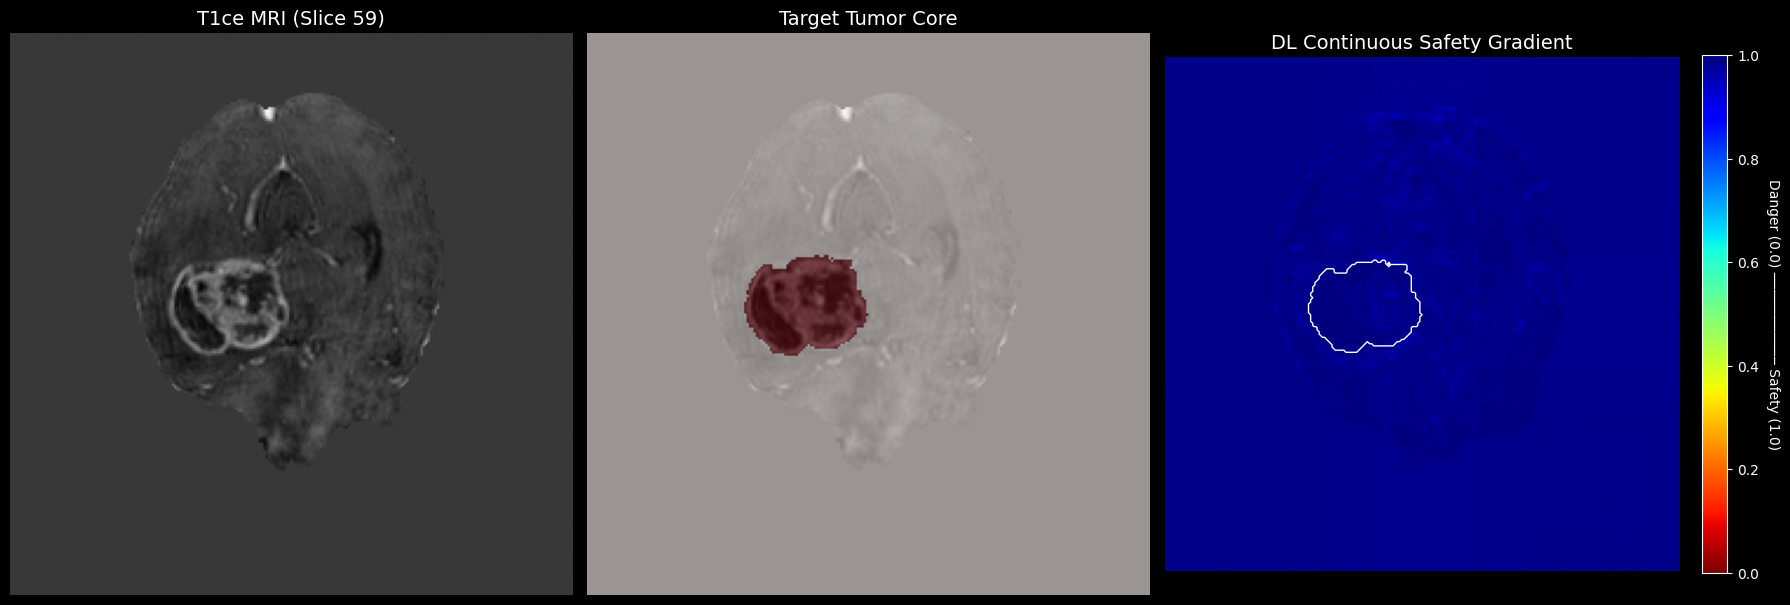

In [4]:
z_slice = np.argmax(tumor_mask.sum(axis=(0, 1)))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Structural MRI (T1ce)
axes[0].imshow(img_data[1, :, :, z_slice].T, cmap="gray", origin="lower")
axes[0].set_title(f"T1ce MRI (Slice {z_slice})", fontsize=14)
axes[0].axis('off')

# 2. Tumor Core Mask
axes[1].imshow(img_data[1, :, :, z_slice].T, cmap="gray", origin="lower")
axes[1].imshow(tumor_mask[:, :, z_slice].T, cmap="Reds", alpha=0.5, origin="lower")
axes[1].set_title("Target Tumor Core", fontsize=14)
axes[1].axis('off')

# 3. Continuous Safety Gradient (The RL Reward Map)
heatmap = axes[2].imshow(continuous_safety[:, :, z_slice].T, cmap="jet_r", origin="lower", vmin=0, vmax=1)
axes[2].contour(tumor_mask[:, :, z_slice].T, colors='white', linewidths=1)
axes[2].set_title("DL Continuous Safety Gradient", fontsize=14)
axes[2].axis('off')

# Add colorbar
cbar = fig.colorbar(heatmap, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Danger (0.0) ─────────── Safety (1.0)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [5]:
pio.renderers.default = "kaggle"

# Aggressive downsampling so Kaggle's browser doesn't crash (1/3 resolution)
ds = 3

# Extract geometries
d_tumor = np.argwhere(tumor_mask[::ds, ::ds, ::ds]) * ds

# Severe Danger (Probability < 0.2)
severe_danger = (continuous_safety < 0.2) & ~tumor_mask
d_severe = np.argwhere(severe_danger[::ds, ::ds, ::ds]) * ds

# Moderate Risk (Probability between 0.2 and 0.5)
moderate_risk = (continuous_safety >= 0.2) & (continuous_safety < 0.5) & ~tumor_mask
d_moderate = np.argwhere(moderate_risk[::ds, ::ds, ::ds]) * ds

print("[SYSTEM] Assembling 3D Gradient Visualization...")
fig = go.Figure()

# Layer 1: Tumor Core
fig.add_trace(go.Scatter3d(
    x=d_tumor[:, 2], y=d_tumor[:, 1], z=d_tumor[:, 0],
    mode='markers', marker=dict(size=2, color='red', opacity=0.3),
    name='Tumor Core'
))

# Layer 2: Severe Danger Zone (Dark Blue)
fig.add_trace(go.Scatter3d(
    x=d_severe[:, 2], y=d_severe[:, 1], z=d_severe[:, 0],
    mode='markers', marker=dict(size=1.5, color='darkblue', opacity=0.05),
    name='Severe Danger (P < 0.2)'
))

# Layer 3: Moderate Risk Zone (Cyan/Light Blue)
fig.add_trace(go.Scatter3d(
    x=d_moderate[:, 2], y=d_moderate[:, 1], z=d_moderate[:, 0],
    mode='markers', marker=dict(size=1.5, color='cyan', opacity=0.02),
    name='Moderate Risk (0.2 < P < 0.5)'
))

fig.update_layout(
    title=dict(text=f"Continuous Safety Topology - {patient_id}", font=dict(size=16)),
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data',
        camera=dict(eye=dict(x=1.2, y=1.2, z=1.2))
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

[SYSTEM] Assembling 3D Gradient Visualization...


In [6]:
from scipy.ndimage import distance_transform_edt

print("[SYSTEM] Finalizing Deep Learning Surgical Context...")

# 1. Calculate Tumor Centroid
tumor_coords = np.argwhere(tumor_mask)
centroid = tumor_coords.mean(axis=0).astype(int)
print(f"  -> Tumor Centroid located at: {centroid}")

# 2. Extract Brain Surface (Simple Thresholding on T1ce)
# A voxel is considered "brain" if it has signal > 0
brain_mask = img_data[1] > 0.01 

# 3. Calculate the Optimal Entry Point (Burr Hole)
# We find the highest Z (superior) point of the brain mask that is directly 
# above the tumor centroid (X, Y) to simulate a standard cranial approach.
z_candidates = np.argwhere(brain_mask[:, centroid[1], centroid[2]])
if len(z_candidates) > 0:
    entry_point = np.array([z_candidates.max(), centroid[1], centroid[2]])
else:
    # Fallback if standard raycast fails: highest point of the tumor + margin
    entry_point = np.array([tumor_coords[:, 0].max() + 10, centroid[1], centroid[2]])
    entry_point = np.clip(entry_point, 0, np.array(brain_mask.shape) - 1)

print(f"  -> Calculated Skull Entry Point (Burr Hole): {entry_point}")

# 4. Generate Physical Distance Buffer (The "Surgical Cost Map")
# We want the agent to know physically how many voxels away the severe danger is.
severe_danger_mask = (continuous_safety < 0.2)
if severe_danger_mask.sum() > 0:
    # distance_transform_edt measures distance FROM 0s TO nearest 1.
    # So we invert the danger mask. 0 = Danger, 1 = Safe.
    physical_distance_map = distance_transform_edt(~severe_danger_mask)
else:
    physical_distance_map = np.ones_like(continuous_safety) * 100.0

# 5. Package and Update the .npz File
# We rewrite the file to include these new kinematic necessities
save_path = os.path.join(OUTPUT_DIR, f"{patient_id}_continuous_safety.npz")
np.savez_compressed(
    save_path, 
    safety_gradient=continuous_safety,    # The AI probability
    physical_distance=physical_distance_map, # The Mathematical distance buffer
    tumor_mask=tumor_mask,                # The Target
    centroid=centroid,                    # The Core
    entry_point=entry_point               # The Kinematic Pivot
)

print(f"[SUCCESS] Surgical Context fully compiled and saved to: {save_path}")
print("="*60)
print("DEEP LEARNING PERCEPTION PHASE: 100% COMPLETE.")
print("Proceed to SOTA PPO Reinforcement Learning.")
print("="*60)

[SYSTEM] Finalizing Deep Learning Surgical Context...
  -> Tumor Centroid located at: [ 91 123  60]
  -> Calculated Skull Entry Point (Burr Hole): [182 123  60]
[SUCCESS] Surgical Context fully compiled and saved to: /kaggle/working/continuous_maps/BraTS20_Training_001_continuous_safety.npz
DEEP LEARNING PERCEPTION PHASE: 100% COMPLETE.
Proceed to SOTA PPO Reinforcement Learning.
